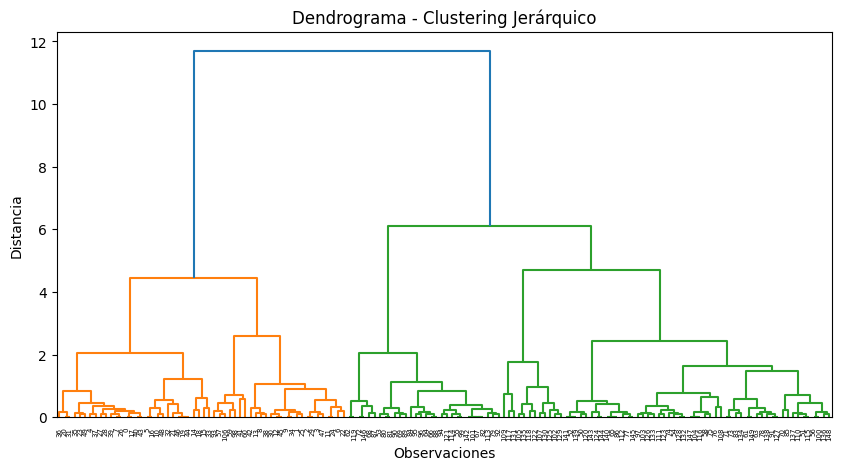

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.datasets import load_iris

# Dataset
data = load_iris()
X = data.data[:, :2]  # usamos solo dos variables para visualizar

# Construcción del clustering jerárquico
Z = linkage(X, method='ward')

# Dendrograma
plt.figure(figsize=(10,5))
dendrogram(Z)
plt.title("Dendrograma - Clustering Jerárquico")
plt.xlabel("Observaciones")
plt.ylabel("Distancia")
plt.show()

| Método     | Idea                                    |
| ---------- | --------------------------------------- |
| `single`   | distancia mínima entre puntos           |
| `complete` | distancia máxima                        |
| `average`  | promedio de distancias                  |
| `ward`     | minimiza la varianza dentro del cluster |


## Selección del Valor de K

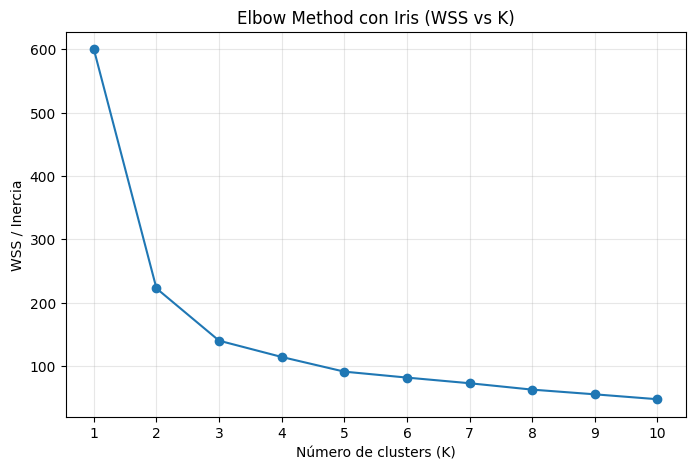

In [ ]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1) Cargar Iris
iris = load_iris()
X = iris.data  # (150, 4) -> sepal length/width, petal length/width

# 2) Escalar (recomendado para K-Means)
X_scaled = StandardScaler().fit_transform(X)

# 3) Elbow: calcular WSS/Inercia para varios K
k_values = range(1, 11)
wss = []

for k in k_values:
    km = KMeans(
        n_clusters=k,
        init="k-means++",
        n_init=10,
        random_state=42
    )
    km.fit(X_scaled)
    wss.append(km.inertia_)  # inertia_ = WSS

# 4) Graficar
plt.figure(figsize=(8, 5))
plt.plot(list(k_values), wss, marker="o")
plt.title("Elbow Method con Iris (WSS vs K)")
plt.xlabel("Número de clusters (K)")
plt.ylabel("WSS / Inercia")
plt.xticks(list(k_values))
plt.grid(True, alpha=0.3)
plt.show()

De K = 1 a K = 2 la caída es enorme (de ~600 a ~225).

De K = 2 a K = 3 sigue bajando bastante (hasta ~140).

Después de K = 3 la curva empieza a aplanarse y las mejoras son mucho más pequeñas.

## Coeficiente de Silueta

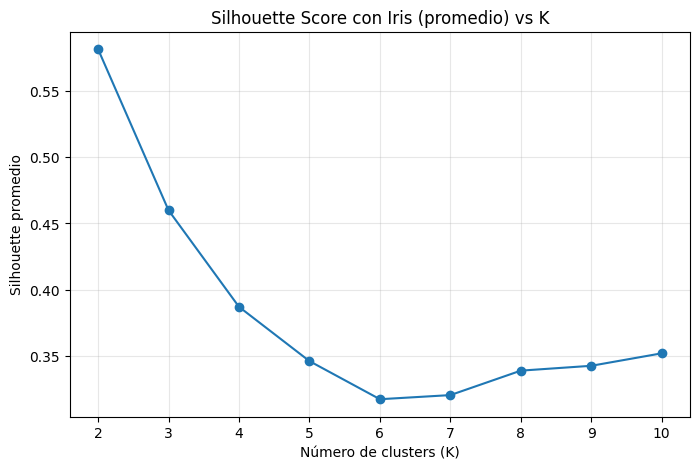

Mejor K según Silhouette: 2 (score=0.582)


In [ ]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# 1) Cargar Iris
iris = load_iris()
X = iris.data  # 4 variables numéricas

# 2) Escalar (recomendado)
X_scaled = StandardScaler().fit_transform(X)

# 3) Probar varios K y calcular Silhouette promedio
k_values = range(2, 11)  # Silhouette se define desde K=2
sil_scores = []

for k in k_values:
    km = KMeans(
        n_clusters=k,
        init="k-means++",
        n_init=10,
        random_state=42
    )
    labels = km.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels))

# 4) Graficar Silhouette vs K
plt.figure(figsize=(8, 5))
plt.plot(list(k_values), sil_scores, marker="o")
plt.title("Silhouette Score con Iris (promedio) vs K")
plt.xlabel("Número de clusters (K)")
plt.ylabel("Silhouette promedio")
plt.xticks(list(k_values))
plt.grid(True, alpha=0.3)
plt.show()

# 5) Mostrar el mejor K según Silhouette
best_k = list(k_values)[sil_scores.index(max(sil_scores))]
print(f"Mejor K según Silhouette: {best_k} (score={max(sil_scores):.3f})")

El método del codo sugiere tres clusters, lo cual coincide con las tres especies del dataset. Sin embargo, el coeficiente de silueta sugiere dos clusters porque Versicolor y Virginica se superponen bastante, por lo que el modelo encuentra más coherente agruparlas juntas.

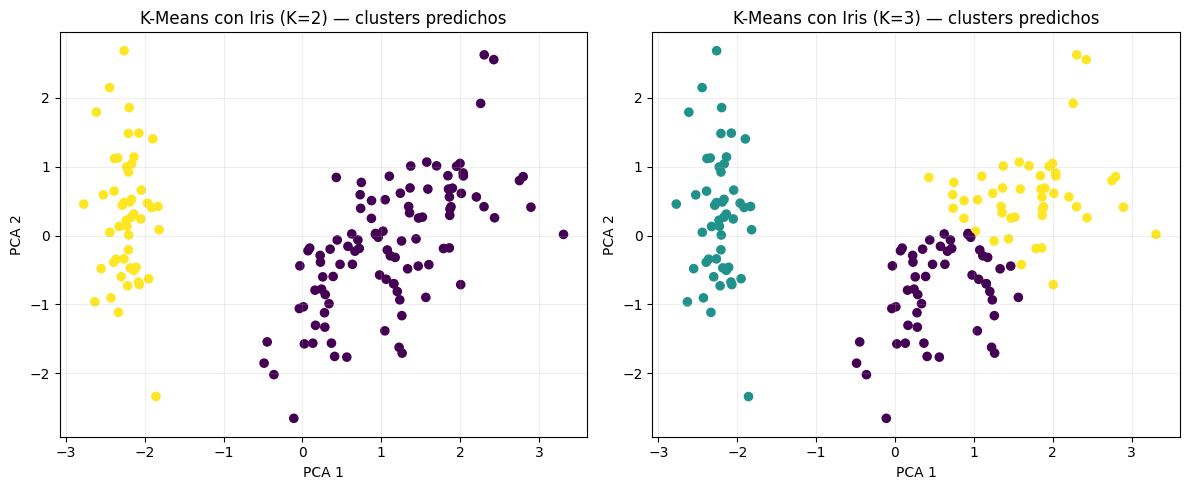

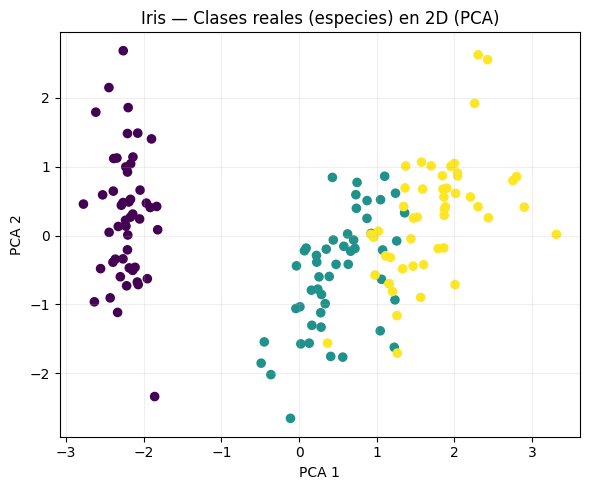

In [ ]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# 1) Cargar Iris
iris = load_iris()
X = iris.data
y = iris.target  # especies reales (0,1,2)

# 2) Escalar
X_scaled = StandardScaler().fit_transform(X)

# 3) Reducir a 2D para poder graficar (PCA)
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_scaled)

def plot_kmeans(ax, k, title):
    km = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)

    ax.scatter(X_2d[:, 0], X_2d[:, 1], c=labels, s=35)
    ax.set_title(title)
    ax.set_xlabel("PCA 1")
    ax.set_ylabel("PCA 2")
    ax.grid(True, alpha=0.2)

# 4) Graficar comparación K=2 vs K=3
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_kmeans(axes[0], 2, "K-Means con Iris (K=2) — clusters predichos")
plot_kmeans(axes[1], 3, "K-Means con Iris (K=3) — clusters predichos")
plt.tight_layout()
plt.show()

# 5) Graficar especies reales (para contrastar)
plt.figure(figsize=(6, 5))
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y, s=35)
plt.title("Iris — Clases reales (especies) en 2D (PCA)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

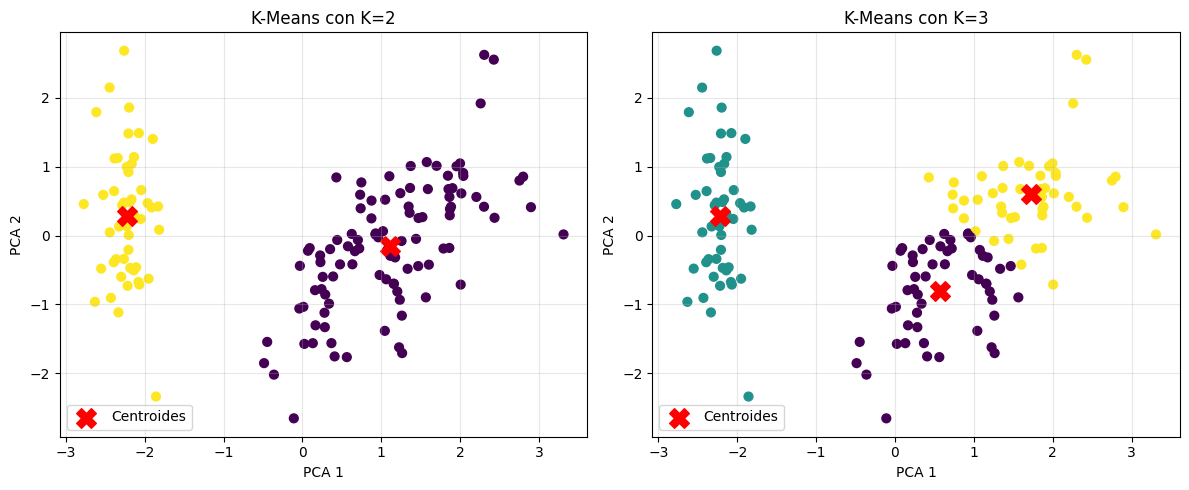

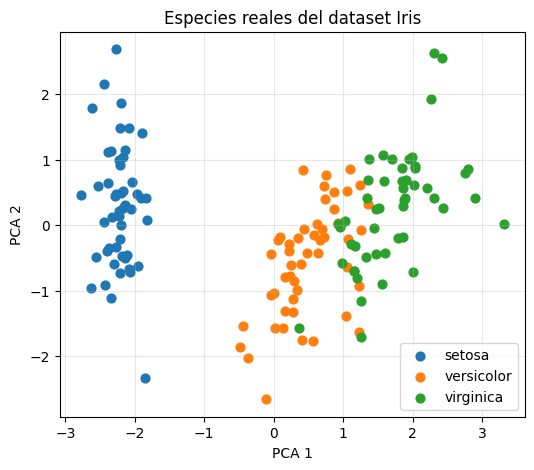

In [ ]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# 1) Cargar dataset
iris = load_iris()
X = iris.data
y = iris.target
species = iris.target_names

# 2) Escalar variables
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3) Reducir dimensiones para visualizar
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

def plot_kmeans(ax, k):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)

    # Centroides proyectados al espacio PCA
    centroids = pca.transform(kmeans.cluster_centers_)

    scatter = ax.scatter(X_pca[:,0], X_pca[:,1], c=labels, s=40)
    ax.scatter(centroids[:,0], centroids[:,1], c="red", marker="X", s=200, label="Centroides")

    ax.set_title(f"K-Means con K={k}")
    ax.set_xlabel("PCA 1")
    ax.set_ylabel("PCA 2")
    ax.legend()
    ax.grid(alpha=0.3)

# 4) Comparar K=2 vs K=3
fig, axes = plt.subplots(1,2, figsize=(12,5))

plot_kmeans(axes[0], 2)
plot_kmeans(axes[1], 3)

plt.tight_layout()
plt.show()

# 5) Mostrar las clases reales
plt.figure(figsize=(6,5))
for i, name in enumerate(species):
    plt.scatter(
        X_pca[y == i,0],
        X_pca[y == i,1],
        label=name,
        s=40
    )

plt.title("Especies reales del dataset Iris")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Discusión de Resultados

Al aplicar K-Means al dataset Iris, utilizamos dos métodos para evaluar el número adecuado de clusters: el método del codo y el coeficiente de silueta.

El método del codo sugiere que un valor razonable para
𝐾
K es 3, ya que a partir de ese punto la reducción del error dentro de los clusters (WSS) comienza a disminuir de manera más gradual. Este resultado coincide con el conocimiento del dataset, que contiene tres especies de flores: Setosa, Versicolor y Virginica.

Sin embargo, el coeficiente de silueta muestra que el valor más alto se obtiene cuando K = 2. Esto ocurre porque, en el espacio de variables, la especie Setosa está claramente separada, mientras que Versicolor y Virginica presentan una superposición considerable. Desde la perspectiva de la separación geométrica de los datos, el algoritmo encuentra más coherente dividirlos en dos grupos: uno correspondiente a Setosa y otro que agrupa a las otras dos especies.

Este resultado ilustra un punto importante en clustering: diferentes métricas pueden sugerir distintos números de clusters, y la decisión final debe considerar tanto los indicadores cuantitativos como el conocimiento del dominio y la interpretación de los datos.

En este caso, aunque el coeficiente de silueta favorece
K=2, utilizar
K=3 permite identificar las tres especies reales del dataset, lo que puede ser más útil desde una perspectiva interpretativa.

## DBSCAN

Clusters encontrados: 2
Puntos ruido (-1): 26
Etiquetas únicas: {np.int64(0), np.int64(1), np.int64(-1)}


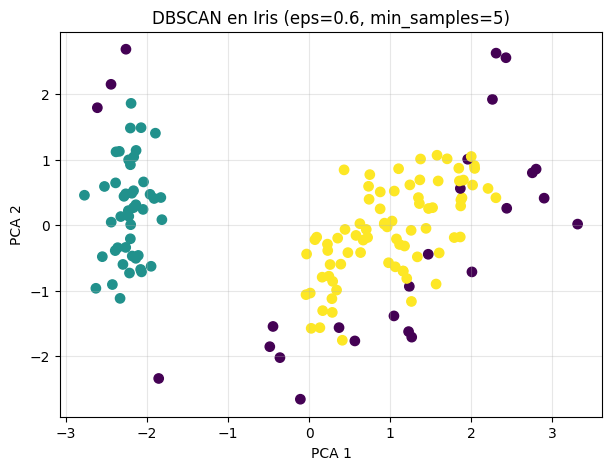

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA

# 1) Cargar Iris
iris = load_iris()
X = iris.data
y = iris.target  # especies reales (solo para comparar / curiosidad)

# 2) Escalar (clave para DBSCAN porque usa distancias)
X_scaled = StandardScaler().fit_transform(X)

# 3) Entrenar DBSCAN
# Ojo: estos valores son un punto de partida. Ajusta eps si te da mucho ruido o 1 solo cluster.
db = DBSCAN(eps=0.6, min_samples=5)
labels = db.fit_predict(X_scaled)  # -1 = ruido

# 4) Resumen de resultados
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = np.sum(labels == -1)

print("Clusters encontrados:", n_clusters)
print("Puntos ruido (-1):", n_noise)
print("Etiquetas únicas:", set(labels))

# 5) Visualización en 2D con PCA (solo para graficar)
X_pca = PCA(n_components=2, random_state=42).fit_transform(X_scaled)

plt.figure(figsize=(7, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, s=45)
plt.title(f"DBSCAN en Iris (eps={db.eps}, min_samples={db.min_samples})")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.grid(alpha=0.3)
plt.show()

## LIVE CODING 1

Imports y dataset Two Moons

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score

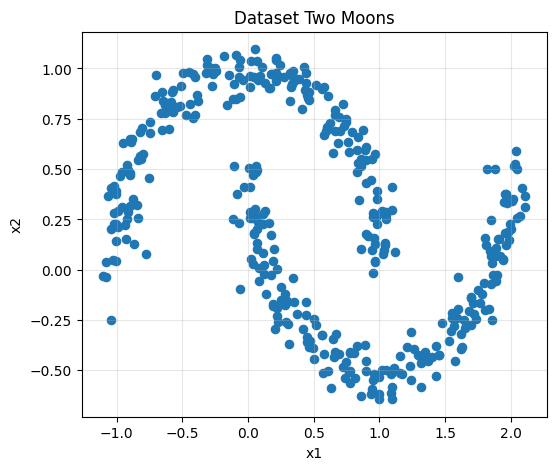

In [ ]:
# Generar Two Moons
X, y_true = make_moons(n_samples=400, noise=0.07, random_state=42)

plt.figure(figsize=(6,5))
plt.scatter(X[:,0], X[:,1], s=35)
plt.title("Dataset Two Moons")
plt.xlabel("x1"); plt.ylabel("x2")
plt.grid(alpha=0.3)
plt.show()

**K-Means**

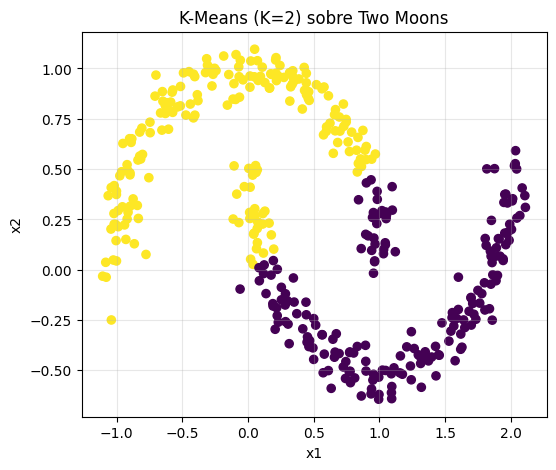

Silhouette K-Means: 0.492


In [ ]:
X_scaled = StandardScaler().fit_transform(X)

kmeans = KMeans(n_clusters=2, init="k-means++", n_init=10, random_state=42)
labels_km = kmeans.fit_predict(X_scaled)

plt.figure(figsize=(6,5))
plt.scatter(X[:,0], X[:,1], c=labels_km, s=35)
plt.title("K-Means (K=2) sobre Two Moons")
plt.xlabel("x1"); plt.ylabel("x2")
plt.grid(alpha=0.3)
plt.show()

print("Silhouette K-Means:", round(silhouette_score(X_scaled, labels_km), 3))

**DBSCAN**

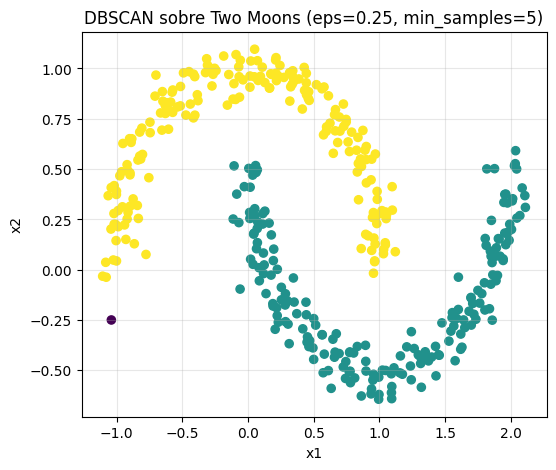

Clusters encontrados: 2
Puntos ruido (-1): 1
Silhouette DBSCAN (sin ruido): 0.379


In [ ]:
db = DBSCAN(eps=0.25, min_samples=5)  # prueba inicial
labels_db = db.fit_predict(X_scaled)

n_clusters = len(set(labels_db)) - (1 if -1 in labels_db else 0)
n_noise = np.sum(labels_db == -1)

plt.figure(figsize=(6,5))
plt.scatter(X[:,0], X[:,1], c=labels_db, s=35)
plt.title(f"DBSCAN sobre Two Moons (eps={db.eps}, min_samples={db.min_samples})")
plt.xlabel("x1"); plt.ylabel("x2")
plt.grid(alpha=0.3)
plt.show()

print("Clusters encontrados:", n_clusters)
print("Puntos ruido (-1):", n_noise)

# Silhouette solo si hay al menos 2 clusters (ignorando ruido)
mask = labels_db != -1
if len(set(labels_db[mask])) >= 2:
    print("Silhouette DBSCAN (sin ruido):", round(silhouette_score(X_scaled[mask], labels_db[mask]), 3))
else:
    print("Silhouette DBSCAN: no aplica (menos de 2 clusters sin ruido).")

**Comparación lado a lado**

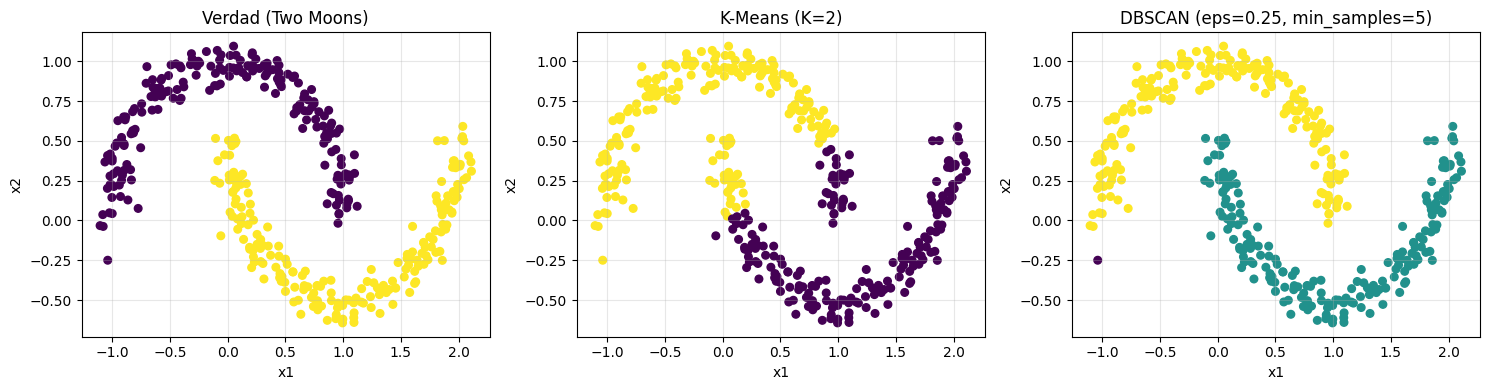

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(X[:,0], X[:,1], c=y_true, s=30)
axes[0].set_title("Verdad (Two Moons)")
axes[0].grid(alpha=0.3)

axes[1].scatter(X[:,0], X[:,1], c=labels_km, s=30)
axes[1].set_title("K-Means (K=2)")
axes[1].grid(alpha=0.3)

axes[2].scatter(X[:,0], X[:,1], c=labels_db, s=30)
axes[2].set_title(f"DBSCAN (eps={db.eps}, min_samples={db.min_samples})")
axes[2].grid(alpha=0.3)

for ax in axes:
    ax.set_xlabel("x1"); ax.set_ylabel("x2")

plt.tight_layout()
plt.show()

**“Tuning” rápido de eps**

In [ ]:
eps_values = np.linspace(0.15, 0.40, 11)
min_samples = 5

results = []
for eps in eps_values:
    db = DBSCAN(eps=float(eps), min_samples=min_samples)
    labels = db.fit_predict(X_scaled)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = np.sum(labels == -1)

    mask = labels != -1
    sil = None
    if len(set(labels[mask])) >= 2:
        sil = silhouette_score(X_scaled[mask], labels[mask])

    results.append((eps, n_clusters, n_noise, sil))

for eps, nc, nn, sil in results:
    sil_txt = "NA" if sil is None else f"{sil:.3f}"
    print(f"eps={eps:.2f} | clusters={nc} | ruido={nn} | silhouette={sil_txt}")

eps=0.15 | clusters=8 | ruido=21 | silhouette=0.253
eps=0.17 | clusters=4 | ruido=10 | silhouette=0.072
eps=0.20 | clusters=3 | ruido=3 | silhouette=0.069
eps=0.23 | clusters=2 | ruido=1 | silhouette=0.379
eps=0.25 | clusters=2 | ruido=1 | silhouette=0.379
eps=0.28 | clusters=2 | ruido=1 | silhouette=0.379
eps=0.30 | clusters=2 | ruido=1 | silhouette=0.379
eps=0.33 | clusters=2 | ruido=1 | silhouette=0.379
eps=0.35 | clusters=2 | ruido=1 | silhouette=0.379
eps=0.38 | clusters=2 | ruido=1 | silhouette=0.379
eps=0.40 | clusters=2 | ruido=1 | silhouette=0.379


| eps         | comportamiento                      |
| ----------- | ----------------------------------- |
| muy pequeño | muchos clusters + mucho ruido       |
| adecuado    | clusters correctos                  |
| muy grande  | clusters se mantienen o se fusionan |


En DBSCAN, elegir eps correctamente es fundamental porque controla qué regiones se consideran suficientemente densas para formar un cluster.

El k-distance plot es el método más usado para estimar un buen valor de eps en DBSCAN. La idea es bastante intuitiva cuando se ve el gráfico.

Idea del método
1. Para cada punto se calcula la distancia a su k-ésimo vecino más cercano.
2. Esas distancias se ordenan de menor a mayor.
3. Se grafican.
4. Se busca el punto donde la curva cambia bruscamente de pendiente (un “codo”).

Ese valor suele ser un buen eps.

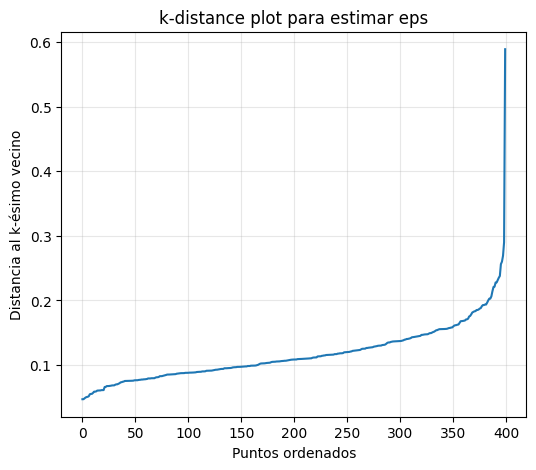

In [ ]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

# k = min_samples que usamos en DBSCAN
k = 5

neighbors = NearestNeighbors(n_neighbors=k)
neighbors_fit = neighbors.fit(X_scaled)

distances, indices = neighbors_fit.kneighbors(X_scaled)

# tomar la distancia al k-ésimo vecino
k_distances = distances[:, k-1]

# ordenar
k_distances = np.sort(k_distances)

plt.figure(figsize=(6,5))
plt.plot(k_distances)
plt.title("k-distance plot para estimar eps")
plt.xlabel("Puntos ordenados")
plt.ylabel("Distancia al k-ésimo vecino")
plt.grid(alpha=0.3)
plt.show()

En el gráfico k-distance ordenamos la distancia al k-ésimo vecino. El punto donde la curva empieza a subir rápidamente indica el límite entre regiones densas y regiones dispersas. Ese valor se utiliza como estimación de eps.

| método          | resultado    |
| --------------- | ------------ |
| tuning eps      | ~0.23 - 0.30 |
| k-distance plot | ~0.23        |
| DBSCAN final    | 2 clusters   |


Visualizar core / border / noise con DBSCAN en Two Moons

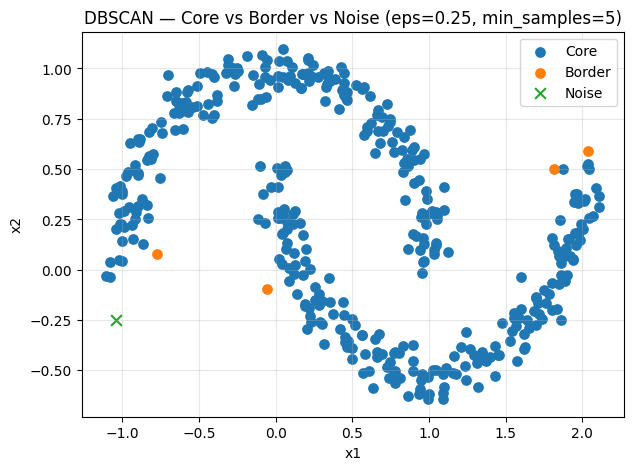

Clusters: 2
Core: 395 | Border: 4 | Noise: 1
Etiquetas únicas: {np.int64(0), np.int64(1), np.int64(-1)}


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN

# Ajusta eps según tu k-distance/tuning
eps = 0.25
min_samples = 5

db = DBSCAN(eps=eps, min_samples=min_samples)
labels = db.fit_predict(X_scaled)

# Identificar tipos de puntos
core_mask = np.zeros_like(labels, dtype=bool)
core_mask[db.core_sample_indices_] = True

noise_mask = labels == -1
border_mask = (~core_mask) & (~noise_mask)

# Para graficar: -1 (ruido) lo dejamos como color aparte
plt.figure(figsize=(7,5))

# Core points
plt.scatter(
    X[core_mask, 0], X[core_mask, 1],
    s=45, marker="o", label="Core"
)

# Border points
plt.scatter(
    X[border_mask, 0], X[border_mask, 1],
    s=45, marker="o", label="Border"
)

# Noise points
plt.scatter(
    X[noise_mask, 0], X[noise_mask, 1],
    s=60, marker="x", label="Noise"
)

plt.title(f"DBSCAN — Core vs Border vs Noise (eps={eps}, min_samples={min_samples})")
plt.xlabel("x1"); plt.ylabel("x2")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

# Resumen rápido
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
print("Clusters:", n_clusters)
print("Core:", core_mask.sum(), "| Border:", border_mask.sum(), "| Noise:", noise_mask.sum())
print("Etiquetas únicas:", set(labels))

# **PARTE 2**

## Métricas de Evaluación

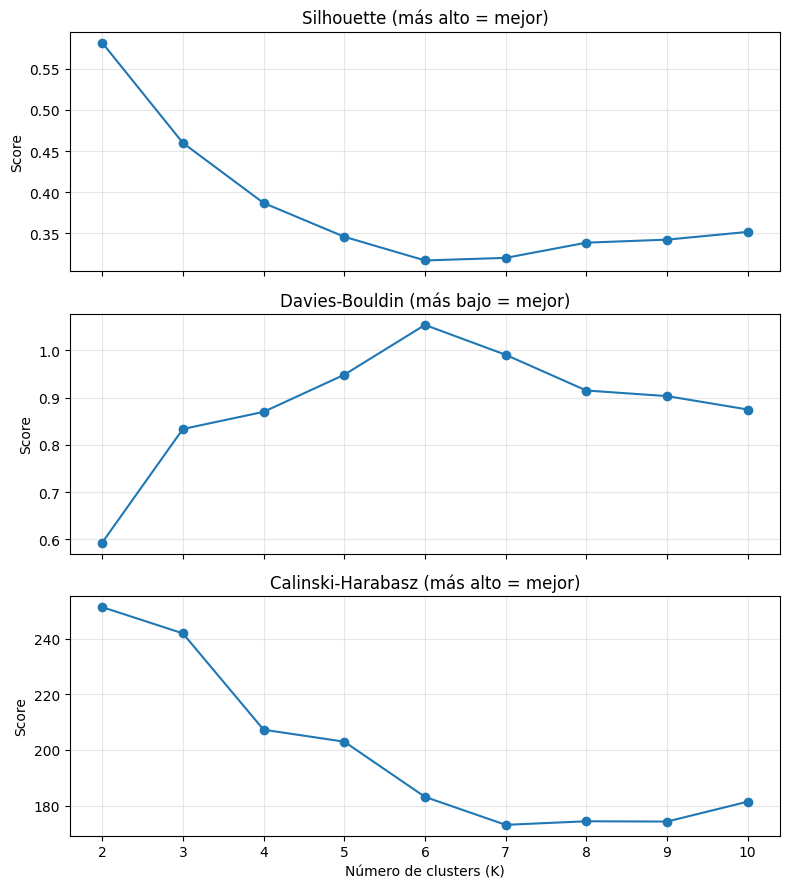

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Datos
iris = load_iris()
X = iris.data
X_scaled = StandardScaler().fit_transform(X)

# Métricas por K
k_values = range(2, 11)
sil_scores, db_scores, ch_scores = [], [], []

for k in k_values:
    km = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels))          # ↑ mejor
    db_scores.append(davies_bouldin_score(X_scaled, labels))       # ↓ mejor
    ch_scores.append(calinski_harabasz_score(X_scaled, labels))    # ↑ mejor

# Gráficos con mismo eje X
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(8, 9), sharex=True)

axes[0].plot(list(k_values), sil_scores, marker="o")
axes[0].set_title("Silhouette (más alto = mejor)")
axes[0].set_ylabel("Score")
axes[0].grid(alpha=0.3)

axes[1].plot(list(k_values), db_scores, marker="o")
axes[1].set_title("Davies-Bouldin (más bajo = mejor)")
axes[1].set_ylabel("Score")
axes[1].grid(alpha=0.3)

axes[2].plot(list(k_values), ch_scores, marker="o")
axes[2].set_title("Calinski-Harabasz (más alto = mejor)")
axes[2].set_xlabel("Número de clusters (K)")
axes[2].set_ylabel("Score")
axes[2].grid(alpha=0.3)

axes[2].set_xticks(list(k_values))

plt.tight_layout()
plt.show()

| Métrica                     | Qué evalúa                                                    | Interpretación                                                                 | Valor óptimo               |
| --------------------------- | ------------------------------------------------------------- | ------------------------------------------------------------------------------ | -------------------------- |
| **Silhouette Score**        | Cohesión del cluster vs separación con otros clusters         | Mide qué tan cerca está un punto de su cluster comparado con el cluster vecino | **Más alto es mejor (≈1)** |
| **Davies-Bouldin Index**    | Similitud entre clusters considerando dispersión interna      | Penaliza clusters muy dispersos o cercanos entre sí                            | **Más bajo es mejor (≈0)** |
| **Calinski-Harabasz Index** | Relación entre dispersión entre clusters y dispersión interna | Favorece clusters bien separados y compactos                                   | **Más alto es mejor**      |


## LIVE CODING 2

El dataset Wine.

Pasos:
1. Escalar variables (muy importante en clustering).
2. Aplicar K-Means.
3. Aplicar DBSCAN.
4. Aplicar Clustering jerárquico.
5. Visualizar con PCA en 2D.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering

# 1 Cargar dataset
wine = load_wine()
X = wine.data

In [ ]:
wine.target_names

array(['class_0', 'class_1', 'class_2'], dtype='<U7')

In [ ]:
import numpy as np
np.bincount(wine.target)

array([59, 71, 48])

In [ ]:
# 2 Escalar datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3 Reducir dimensión para visualizar
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)


**KMEANS**

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42)
labels_kmeans = kmeans.fit_predict(X_scaled)

**DBSCAN**

In [ ]:
dbscan = DBSCAN(eps=0.5, min_samples=5)
labels_dbscan = dbscan.fit_predict(X_scaled)

In [ ]:
#from sklearn.decomposition import PCA

#pca = PCA(n_components=2)
#X_pca = pca.fit_transform(X_scaled)

#dbscan = DBSCAN(eps=0.5, min_samples=5)
#labels_dbscan = dbscan.fit_predict(X_pca)

**JERÁRQUICO**

In [ ]:
hier = AgglomerativeClustering(n_clusters=3)
labels_hier = hier.fit_predict(X_scaled)

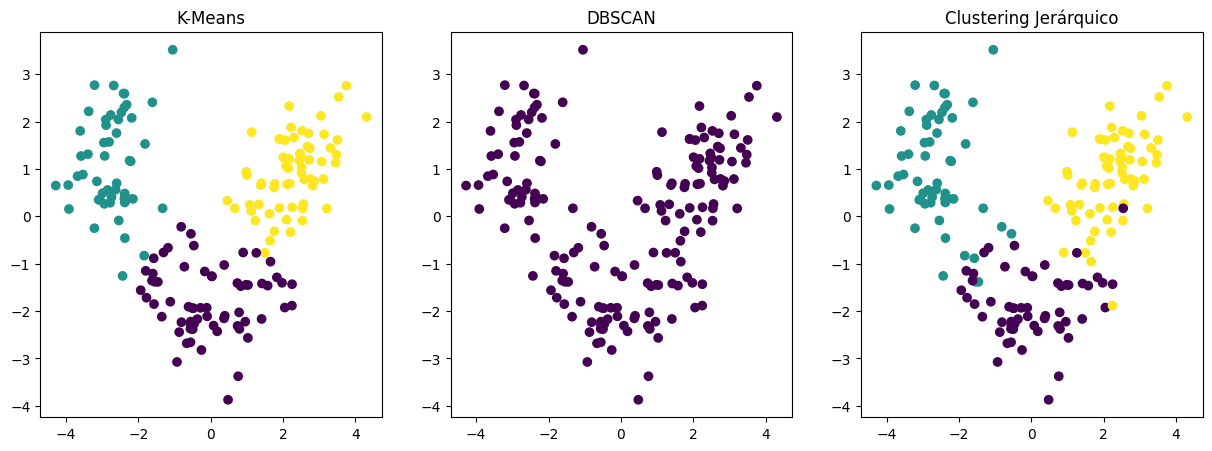

In [ ]:
# ---------------------------
# VISUALIZACIÓN
# ---------------------------

fig, axes = plt.subplots(1,3, figsize=(15,5))

axes[0].scatter(X_pca[:,0], X_pca[:,1], c=labels_kmeans)
axes[0].set_title("K-Means")

axes[1].scatter(X_pca[:,0], X_pca[:,1], c=labels_dbscan)
axes[1].set_title("DBSCAN")

axes[2].scatter(X_pca[:,0], X_pca[:,1], c=labels_hier)
axes[2].set_title("Clustering Jerárquico")

plt.show()

**1 K-Means**

En el gráfico se ven tres clusters bastante claros.

Esto tiene sentido porque:
* El dataset Wine tiene realmente 3 clases
* K-Means funciona muy bien cuando los clusters son compactos y relativamente esféricos

Por eso en este dataset suele dar resultados bastante buenos.

**2 Clustering jerárquico**

El resultado es muy parecido a K-Means.

Esto ocurre porque:
* El dataset tiene una estructura bastante separable
* Al pedir n_clusters=3, el algoritmo corta el dendrograma en ese nivel.

En muchos casos K-Means y jerárquico terminan generando resultados similares.

**3 DBSCAN**

Aquí aparece algo interesante: no está separando los clusters.

Esto no significa que DBSCAN esté mal.

Lo que pasa es que:

DBSCAN depende fuertemente de dos parámetros:
* eps → radio de vecindad
* min_samples → mínimo de puntos para formar un cluster

En la ejecución, el eps probablemente es demasiado grande, por lo que el algoritmo interpreta casi todo como un único cluster denso.

Esto es un comportamiento muy común en datasets de mayor dimensión como Wine (13 variables).

**Silhouette, Davies-Bouldin y Calinski-Harabasz**

**k = 3**

In [4]:
import numpy as np
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# 1) Datos
wine = load_wine()
X = wine.data
X_scaled = StandardScaler().fit_transform(X)

# 2) Modelos
labels_km = KMeans(n_clusters=3, n_init=10, random_state=42).fit_predict(X_scaled)
labels_hc = AgglomerativeClustering(n_clusters=3).fit_predict(X_scaled)
# Ajusta eps/min_samples según tus pruebas
labels_db = DBSCAN(eps=0.5, min_samples=5).fit_predict(X_scaled)

def eval_clustering(name, labels, X_used):
    """ Calcula 3 métricas internas.
    - Para DBSCAN: ignora ruido (-1).
    """
    labels = np.asarray(labels)

    # Ignorar ruido si existe
    mask = labels != -1
    noise_count = int((labels == -1).sum())

    X_eval = X_used[mask]
    y_eval = labels[mask]
    n_clusters = len(set(y_eval))

    # Si queda 0 o 1 cluster, no se pueden calcular bien las métricas
    if n_clusters < 2:
        print(f"{name:12s} | clusters={n_clusters} | ruido={noise_count} | métricas: NA (menos de 2 clusters)")
        return

    sil = silhouette_score(X_eval, y_eval)          # ↑ mejor
    db = davies_bouldin_score(X_eval, y_eval)       # ↓ mejor
    ch = calinski_harabasz_score(X_eval, y_eval)    # ↑ mejor

    print(f"{name:12s} | clusters={n_clusters} | ruido={noise_count} | "
          f"Sil={sil:.3f} | DB={db:.3f} | CH={ch:.1f}")

print("Modelo       | clusters | ruido | Sil(↑) | DB(↓) | CH(↑)")
print("-"*75)
eval_clustering("K-Means", labels_km, X_scaled)
eval_clustering("Jerárquico", labels_hc, X_scaled)
eval_clustering("DBSCAN", labels_db, X_scaled)

Modelo       | clusters | ruido | Sil(↑) | DB(↓) | CH(↑)
---------------------------------------------------------------------------
K-Means      | clusters=3 | ruido=0 | Sil=0.285 | DB=1.389 | CH=70.9
Jerárquico   | clusters=3 | ruido=0 | Sil=0.277 | DB=1.419 | CH=67.6
DBSCAN       | clusters=0 | ruido=178 | métricas: NA (menos de 2 clusters)


**K desde 2 a 6**

In [2]:
import numpy as np
import pandas as pd

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# 1) Datos
wine = load_wine()
X = wine.data
X_scaled = StandardScaler().fit_transform(X)

# 2) Función de evaluación
def calcular_metricas(labels, X_used):
    labels = np.asarray(labels)
    n_clusters = len(set(labels))

    if n_clusters < 2:
        return np.nan, np.nan, np.nan

    sil = silhouette_score(X_used, labels)            # ↑ mejor
    db  = davies_bouldin_score(X_used, labels)        # ↓ mejor
    ch  = calinski_harabasz_score(X_used, labels)     # ↑ mejor

    return sil, db, ch

# 3) Recorrer K para ambos modelos
resultados = []

for k in range(2, 7):
    # K-Means
    labels_km = KMeans(n_clusters=k, n_init=10, random_state=42).fit_predict(X_scaled)
    sil, db, ch = calcular_metricas(labels_km, X_scaled)

    resultados.append({
        "Modelo": "K-Means",
        "K": k,
        "Silhouette": round(sil, 3),
        "Davies-Bouldin": round(db, 3),
        "Calinski-Harabasz": round(ch, 1)
    })

    # Jerárquico
    labels_hc = AgglomerativeClustering(n_clusters=k).fit_predict(X_scaled)
    sil, db, ch = calcular_metricas(labels_hc, X_scaled)

    resultados.append({
        "Modelo": "Jerárquico",
        "K": k,
        "Silhouette": round(sil, 3),
        "Davies-Bouldin": round(db, 3),
        "Calinski-Harabasz": round(ch, 1)
    })

# 4) Tabla final
df_resultados = pd.DataFrame(resultados)
df_resultados = df_resultados.sort_values(by="Modelo")
print(df_resultados)

       Modelo  K  Silhouette  Davies-Bouldin  Calinski-Harabasz
1  Jerárquico  2       0.267           1.412               65.4
3  Jerárquico  3       0.277           1.419               67.6
5  Jerárquico  4       0.226           1.789               51.5
7  Jerárquico  5       0.187           1.923               43.7
9  Jerárquico  6       0.180           1.812               39.1
0     K-Means  2       0.259           1.526               69.5
2     K-Means  3       0.285           1.389               70.9
4     K-Means  4       0.260           1.797               56.2
6     K-Means  5       0.202           1.808               47.0
8     K-Means  6       0.237           1.554               41.7


In [3]:
    # sil  ↑ mejor
    # db   ↓ mejor
    # ch   ↑ mejor